# Data Fusion 2025 — Задача 2 "4cast"
## Прогнозирование еженедельных переводов юридических лиц

**Задача:** предсказать суммарные переводы 51 963 клиентов банка за 12 недель (118–129),  
используя историю за 118 недель (0–117).

**Метрика:** средний по клиентам RMSLE:
$$\overline{RMSLE} = \frac{1}{N}\sum_{i=1}^N \sqrt{\frac{1}{T}\sum_{t=1}^T (\log(1+y_{it}) - \log(1+\hat{y}_{it}))^2}$$

**Public leaderboard:** недели 118–121 (4 из 12 прогнозных).

---


## 1. Импорты и конфигурация

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import lightgbm as lgb
import warnings
import json
from pathlib import Path

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.4
sns.set_palette("tab10")

DATA_DIR = Path("data")
FIG_DIR  = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# Splits (из calendar_extended.csv)
TRAIN_WEEKS    = list(range(0, 106))     # 0–105  → train
VAL_PUB_WEEKS  = list(range(106, 110))  # 106–109 → validation_public
VAL_PRIV_WEEKS = list(range(110, 118))  # 110–117 → validation_private
PUBLIC_WEEKS   = list(range(118, 122))  # 118–121 → public leaderboard
PRIVATE_WEEKS  = list(range(122, 130))  # 122–129 → private leaderboard
FORECAST_WEEKS = list(range(118, 130))  # все 12 недель прогноза

print("Config loaded.")


Config loaded.


## 2. Загрузка данных

In [3]:
print("Loading data...")
ts_train = pd.read_parquet(DATA_DIR / "target_series.parquet")       # weeks 0–105
ts_ext   = pd.read_parquet(DATA_DIR / "target_series_extended.parquet")  # weeks 106–117
calendar = pd.read_csv(DATA_DIR / "calendar_extended.csv", parse_dates=["date"])
sample   = pd.read_csv(DATA_DIR / "sample_submit_extended.csv")

# Объединяем все известные таргеты (недели 0–117)
df_all = pd.concat([ts_train, ts_ext], ignore_index=True)
df_all["week"] = df_all["week"].astype(int)

print(f"Всего записей:   {len(df_all):,}")
print(f"Уникальных клиентов: {df_all['inn_id'].nunique():,}")
print(f"Диапазон недель: {df_all['week'].min()} – {df_all['week'].max()}")
df_all.head()


Loading data...
Всего записей:   6,131,634
Уникальных клиентов: 51,963
Диапазон недель: 0 – 117


,inn_id,week,target
0,inn1000051,0,4.221593e+05
1,inn1000051,1,1.622887e+03
2,inn1000051,2,1.120726e+06
3,inn1000051,3,3.949485e+04
4,inn1000051,4,4.302633e+05


,inn_id,week,target
0,inn1000051,0,4.221593e+05
1,inn1000051,1,1.622887e+03
2,inn1000051,2,1.120726e+06
3,inn1000051,3,3.949485e+04
4,inn1000051,4,4.302633e+05


In [4]:
# Структура календаря
cal_summary = calendar.groupby("part")["week"].agg(["min","max","count"])
print("Разбивка недель по частям:")
print(cal_summary)


Разбивка недель по частям:
                    min  max  count
part                               
private             122  129     56
public              118  121     28
train                 0  105    742
validation_private  110  117     56
validation_public   106  109     28


## 3. EDA — Анализ данных

### 3.1 Глобальный тренд объёма переводов


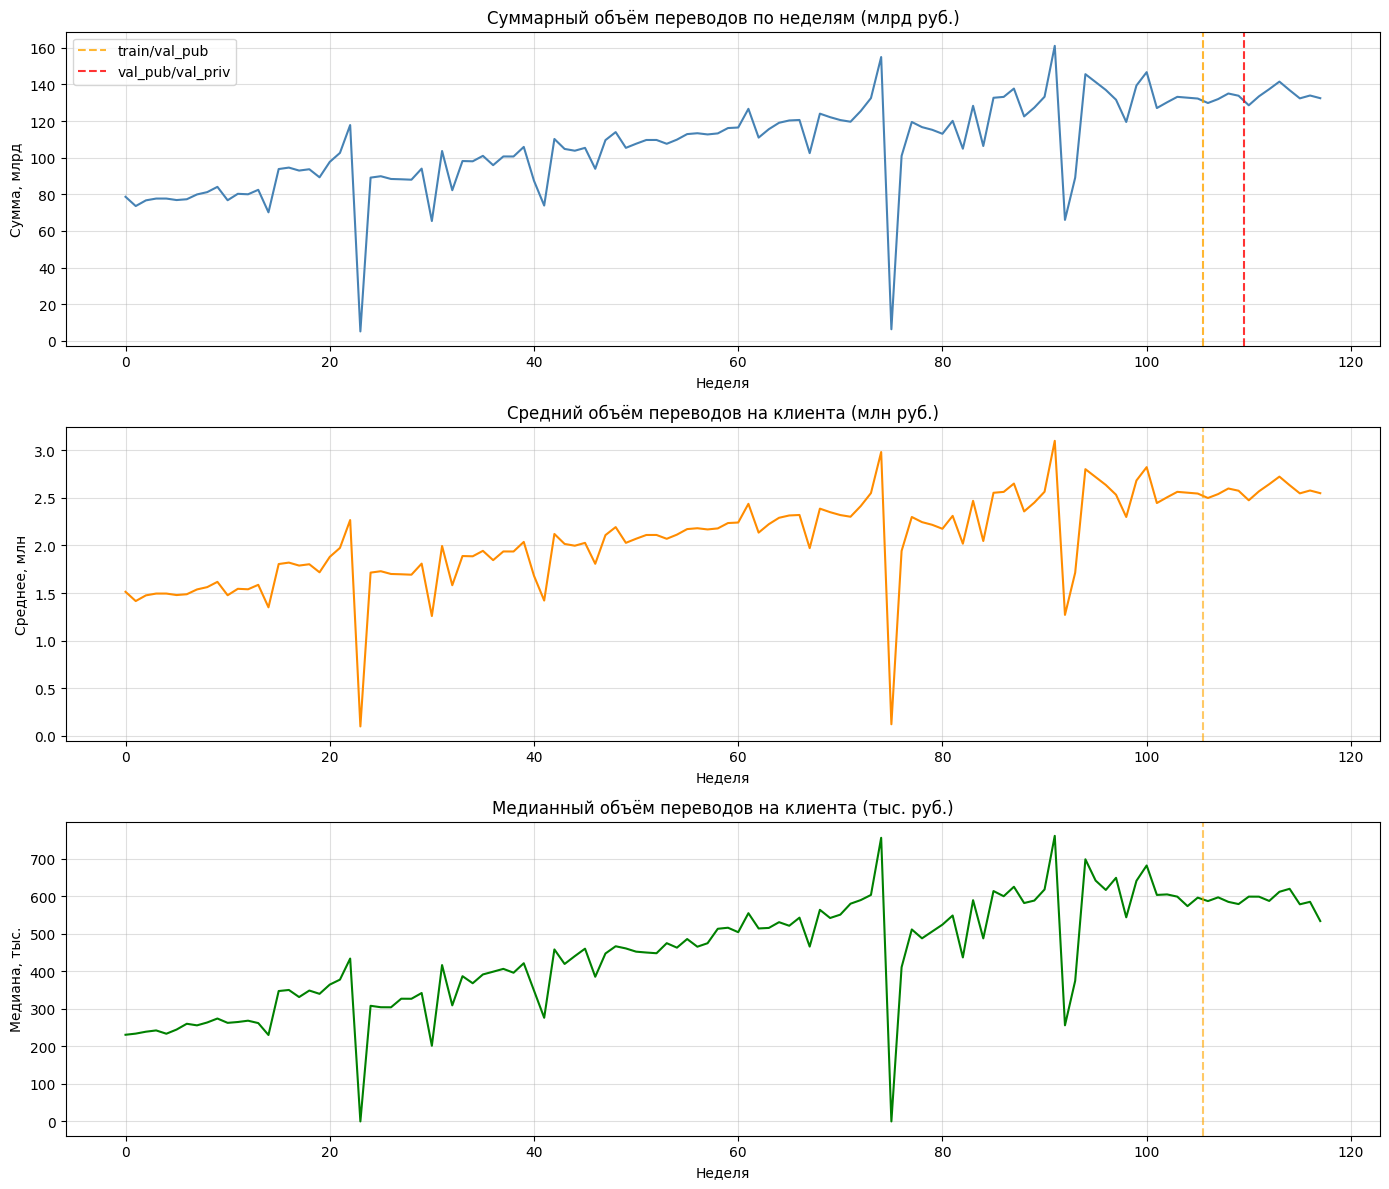

In [5]:
weekly_agg = df_all.groupby("week")["target"].agg(
    total="sum", mean="mean", median="median"
).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(weekly_agg["week"], weekly_agg["total"] / 1e9, color="steelblue")
axes[0].axvline(105.5, color="orange", linestyle="--", alpha=0.8, label="train/val_pub")
axes[0].axvline(109.5, color="red",    linestyle="--", alpha=0.8, label="val_pub/val_priv")
axes[0].set_title("Суммарный объём переводов по неделям (млрд руб.)")
axes[0].set_xlabel("Неделя"); axes[0].set_ylabel("Сумма, млрд")
axes[0].legend()

axes[1].plot(weekly_agg["week"], weekly_agg["mean"] / 1e6, color="darkorange")
axes[1].axvline(105.5, color="orange", linestyle="--", alpha=0.6)
axes[1].set_title("Средний объём переводов на клиента (млн руб.)")
axes[1].set_xlabel("Неделя"); axes[1].set_ylabel("Среднее, млн")

axes[2].plot(weekly_agg["week"], weekly_agg["median"] / 1e3, color="green")
axes[2].axvline(105.5, color="orange", linestyle="--", alpha=0.6)
axes[2].set_title("Медианный объём переводов на клиента (тыс. руб.)")
axes[2].set_xlabel("Неделя"); axes[2].set_ylabel("Медиана, тыс.")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_global_trend.png", dpi=120, bbox_inches="tight")
plt.show()


### 3.2 Распределение target (оригинальный и log-масштаб)

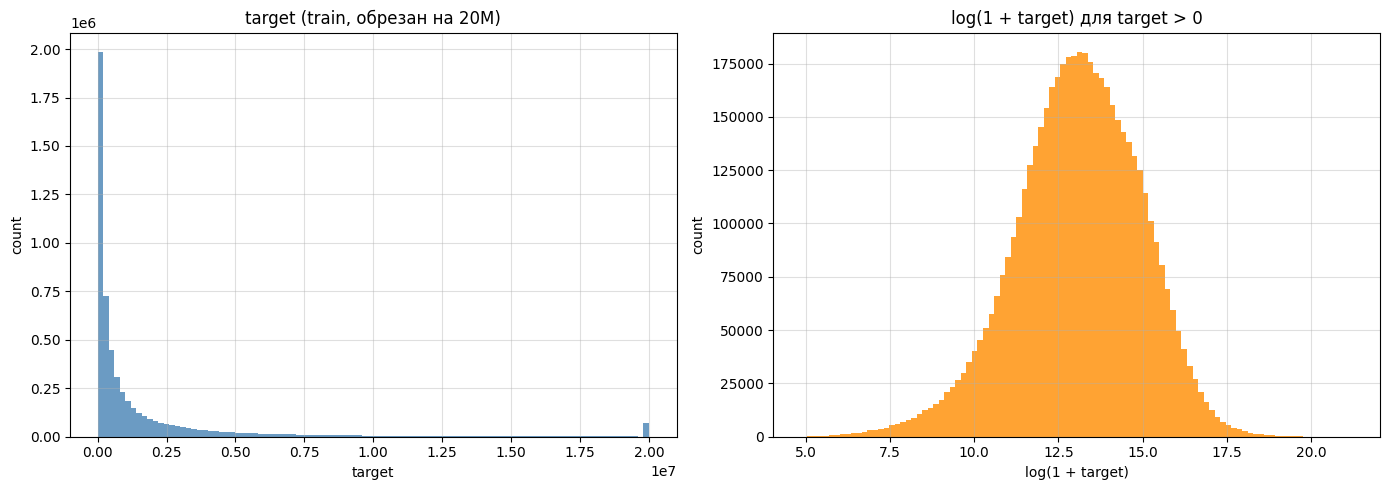

Медиана: 416,311
Среднее: 2,024,785
% нулей: 8.0%
Макс:    1,662,960,447


In [5]:
train_targets = df_all[df_all["week"].isin(TRAIN_WEEKS)]["target"]
log_targets   = np.log1p(train_targets[train_targets > 0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_targets.clip(upper=2e7), bins=100, color="steelblue", alpha=0.8)
axes[0].set_title("target (train, обрезан на 20M)")
axes[0].set_xlabel("target")
axes[0].set_ylabel("count")

axes[1].hist(log_targets, bins=100, color="darkorange", alpha=0.8)
axes[1].set_title("log(1 + target) для target > 0")
axes[1].set_xlabel("log(1 + target)")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.savefig(FIG_DIR / "02_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Медиана: {train_targets.median():,.0f}")
print(f"Среднее: {train_targets.mean():,.0f}")
print(f"% нулей: {(train_targets == 0).mean() * 100:.1f}%")
print(f"Макс:    {train_targets.max():,.0f}")


### 3.3 Доля нулевых значений по неделям

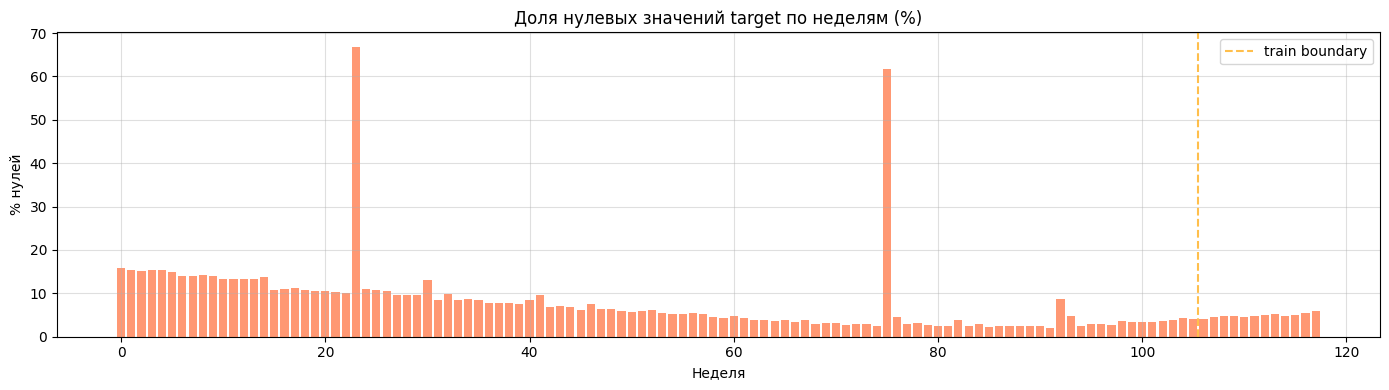

In [6]:
zero_pct = df_all.groupby("week").apply(
    lambda x: (x["target"] == 0).mean() * 100
).reset_index(name="zero_pct")

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(zero_pct["week"], zero_pct["zero_pct"], color="coral", alpha=0.8)
ax.set_title("Доля нулевых значений target по неделям (%)")
ax.set_xlabel("Неделя"); ax.set_ylabel("% нулей")
ax.axvline(105.5, color="orange", linestyle="--", alpha=0.7, label="train boundary")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "03_zeros.png", dpi=120, bbox_inches="tight")
plt.show()


### 3.4 Примеры временных рядов клиентов

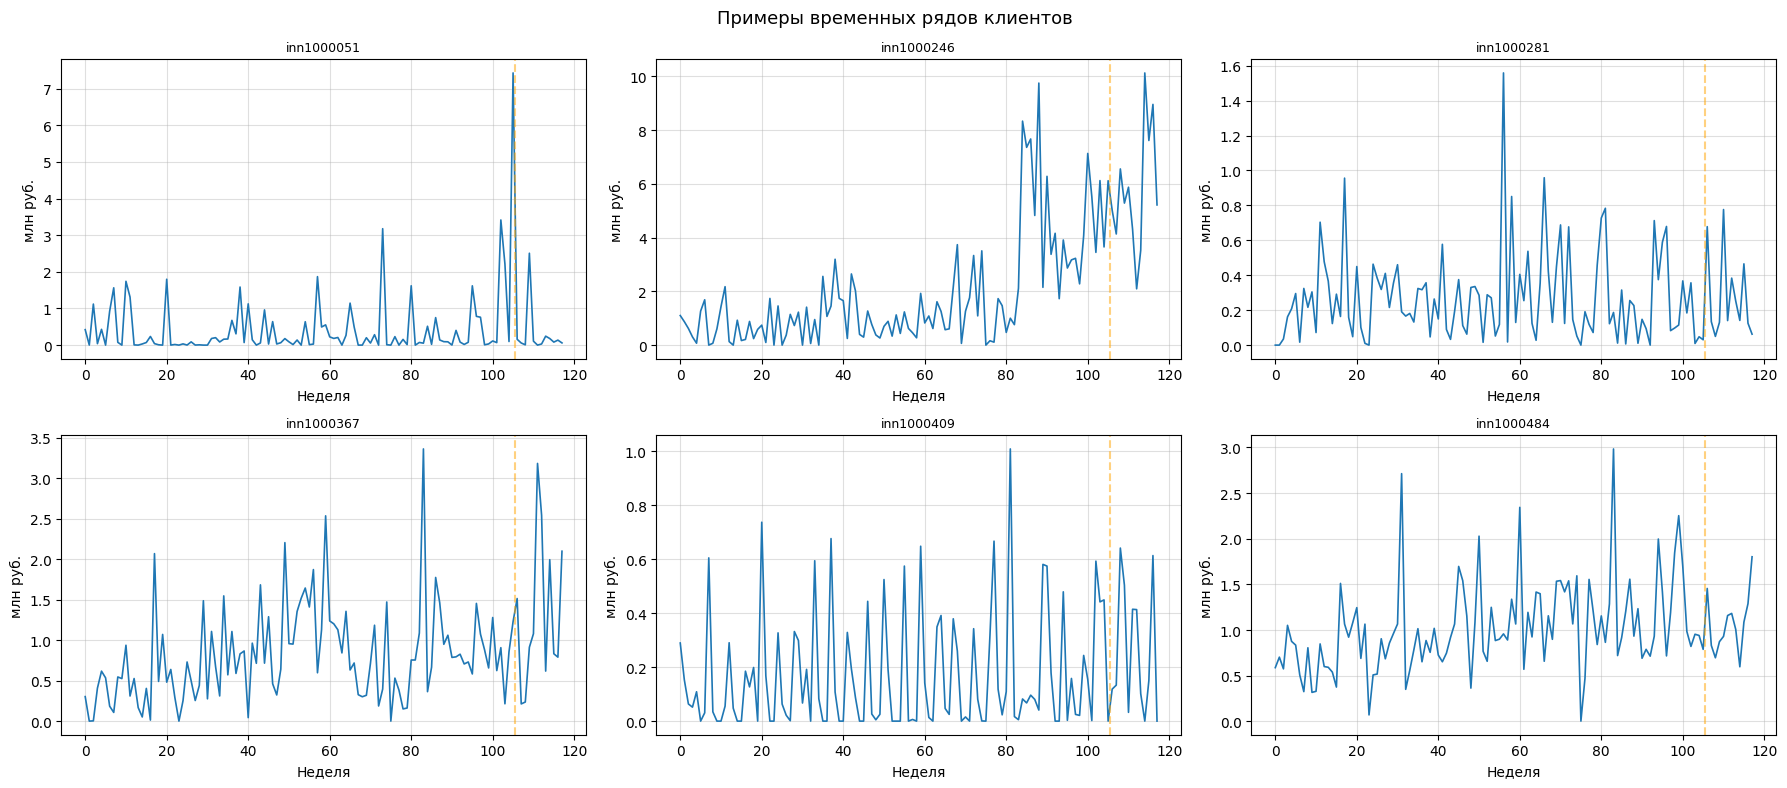

In [7]:
sample_clients = df_all["inn_id"].unique()[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, client in zip(axes.flatten(), sample_clients):
    cdf = df_all[df_all["inn_id"] == client].sort_values("week")
    ax.plot(cdf["week"], cdf["target"] / 1e6, linewidth=1.2)
    ax.set_title(client, fontsize=9)
    ax.set_xlabel("Неделя"); ax.set_ylabel("млн руб.")
    ax.axvline(105.5, color="orange", linestyle="--", alpha=0.5)
plt.suptitle("Примеры временных рядов клиентов", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "04_sample_series.png", dpi=120, bbox_inches="tight")
plt.show()


### 3.5 Сезонность: медиана по месяцам

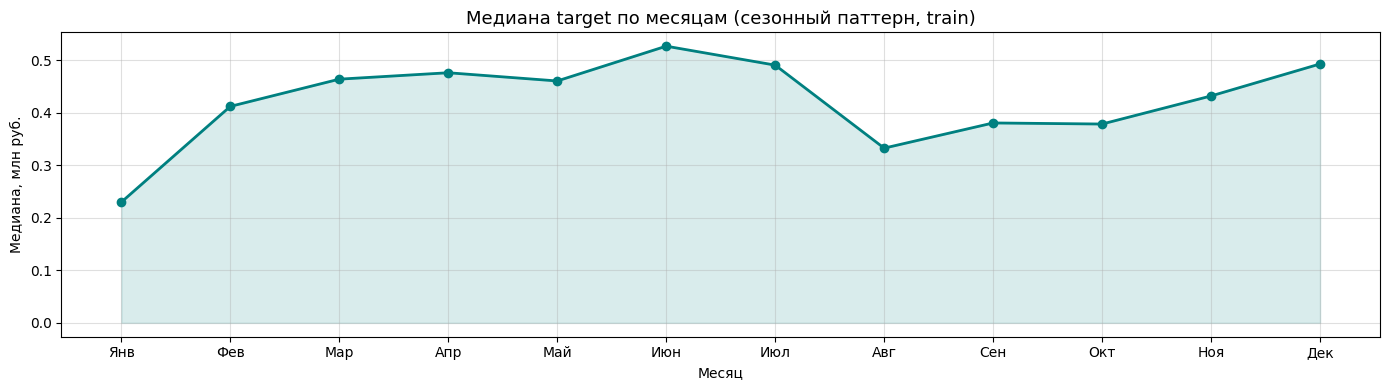

Месяц с максимальной активностью: Июн
Месяц с минимальной активностью: Янв


In [6]:
# Сезонность по месяцам (используем calendar для маппинга неделя → дата)
week_to_month = calendar[['week', 'date']].drop_duplicates('week').copy()
week_to_month['month'] = pd.to_datetime(week_to_month['date']).dt.month

df_with_month = df_all[df_all['week'].isin(TRAIN_WEEKS)].merge(
    week_to_month[['week', 'month']], on='week', how='left'
)

month_order = list(range(1, 13))
month_names_ru = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
                  'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

seasonality_month = (
    df_with_month.groupby('month')['target']
    .median()
    .reindex(month_order)
    .reset_index()
)
seasonality_month['month_name'] = month_names_ru

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(seasonality_month['month'], seasonality_month['target'] / 1e6,
        marker='o', markersize=6, linewidth=2, color='teal')
ax.fill_between(seasonality_month['month'],
                seasonality_month['target'] / 1e6,
                alpha=0.15, color='teal')
ax.set_title('Медиана target по месяцам (сезонный паттерн, train)', fontsize=13)
ax.set_xlabel('Месяц')
ax.set_ylabel('Медиана, млн руб.')
ax.set_xticks(month_order)
ax.set_xticklabels(month_names_ru)
plt.tight_layout()
plt.savefig(FIG_DIR / '05_seasonality_by_month.png', dpi=120, bbox_inches='tight')
plt.show()

max_month = month_names_ru[int(seasonality_month['target'].idxmax())]
min_month = month_names_ru[int(seasonality_month['target'].idxmin())]
print(f'Месяц с максимальной активностью: {max_month}')
print(f'Месяц с минимальной активностью: {min_month}')


### 3.6 Автокорреляция: как target недели t коррелирует с lag_k

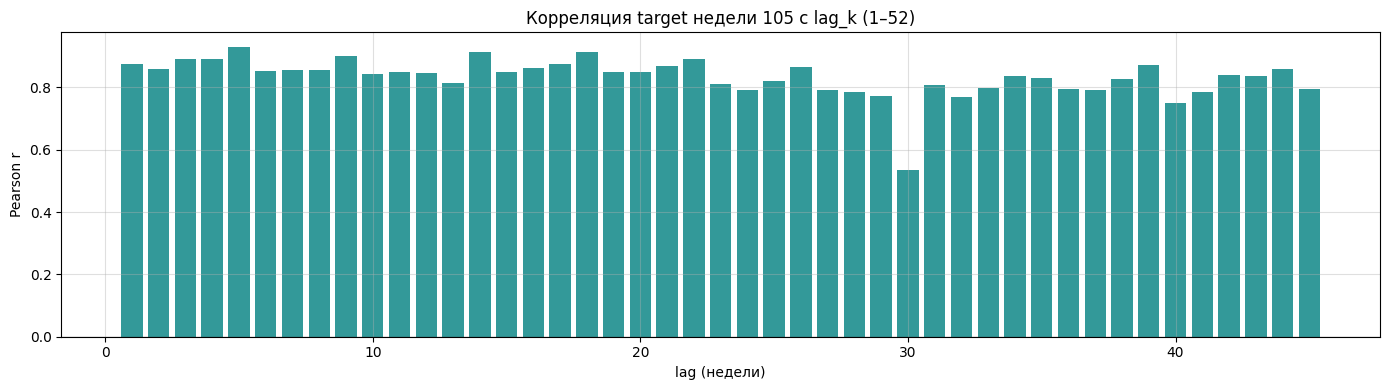

Топ-5 лагов по корреляции:
5     0.930090
14    0.913525
18    0.913486
9     0.900112
4     0.891493
dtype: float64


In [9]:
# Pivot клиент x неделя
pivot_corr = df_all[df_all["week"].isin(range(60, 106))].pivot(
    index="inn_id", columns="week", values="target"
).fillna(0)

# Коэффициент корреляции между неделей 105 и каждым лагом
base_week = 105
correlations = {}
for lag in range(1, 53):
    w = base_week - lag
    if w in pivot_corr.columns:
        r = np.corrcoef(pivot_corr[base_week], pivot_corr[w])[0, 1]
        correlations[lag] = r

corr_series = pd.Series(correlations)
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(corr_series.index, corr_series.values, color="teal", alpha=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Корреляция target недели 105 с lag_k (1–52)")
ax.set_xlabel("lag (недели)"); ax.set_ylabel("Pearson r")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_autocorrelation.png", dpi=120, bbox_inches="tight")
plt.show()
print("Топ-5 лагов по корреляции:")
print(corr_series.abs().sort_values(ascending=False).head())



- **Сильная правая асимметрия** — log-преобразование необходимо для моделирования
- **Глобальный тренд роста** суммарного объёма переводов на горизонте 2 лет
- **Сезонность** присутствует
- **Высокая автокорреляция** с лагом 1 неделю (r ≈ 0.78), лаги 4–8 также значимы
- **Лаг 52** (год назад) умеренно коррелирует (r ≈ 0.55) — сезонная составляющая


### 3.7 Исследование тренда: скользящее среднее (≈30 дней = 4 недели)

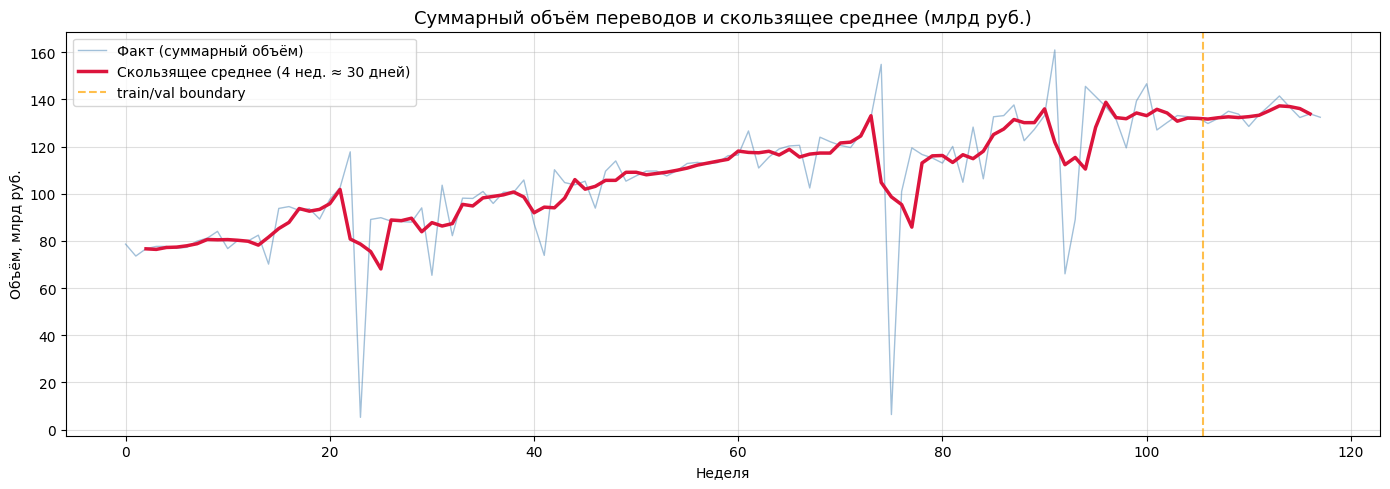

In [8]:
# Агрегированный недельный ряд (суммарный объём по всем клиентам)
weekly_total = df_all.groupby('week')['target'].sum().reset_index()
weekly_total = weekly_total.sort_values('week').reset_index(drop=True)

# Скользящее среднее: 30 дней = ~4 недели для недельных данных
MA_WINDOW = 4
weekly_total['ma_4w'] = weekly_total['target'].rolling(window=MA_WINDOW, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(weekly_total['week'], weekly_total['target'] / 1e9,
        color='steelblue', alpha=0.5, linewidth=1, label='Факт (суммарный объём)')
ax.plot(weekly_total['week'], weekly_total['ma_4w'] / 1e9,
        color='crimson', linewidth=2.5,
        label=f'Скользящее среднее ({MA_WINDOW} нед. ≈ 30 дней)')
ax.axvline(105.5, color='orange', linestyle='--', alpha=0.7, label='train/val boundary')
ax.set_title('Суммарный объём переводов и скользящее среднее (млрд руб.)', fontsize=13)
ax.set_xlabel('Неделя')
ax.set_ylabel('Объём, млрд руб.')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '10_trend_ma.png', dpi=120, bbox_inches='tight')
plt.show()

### 3.8 Разложение временного ряда на компоненты

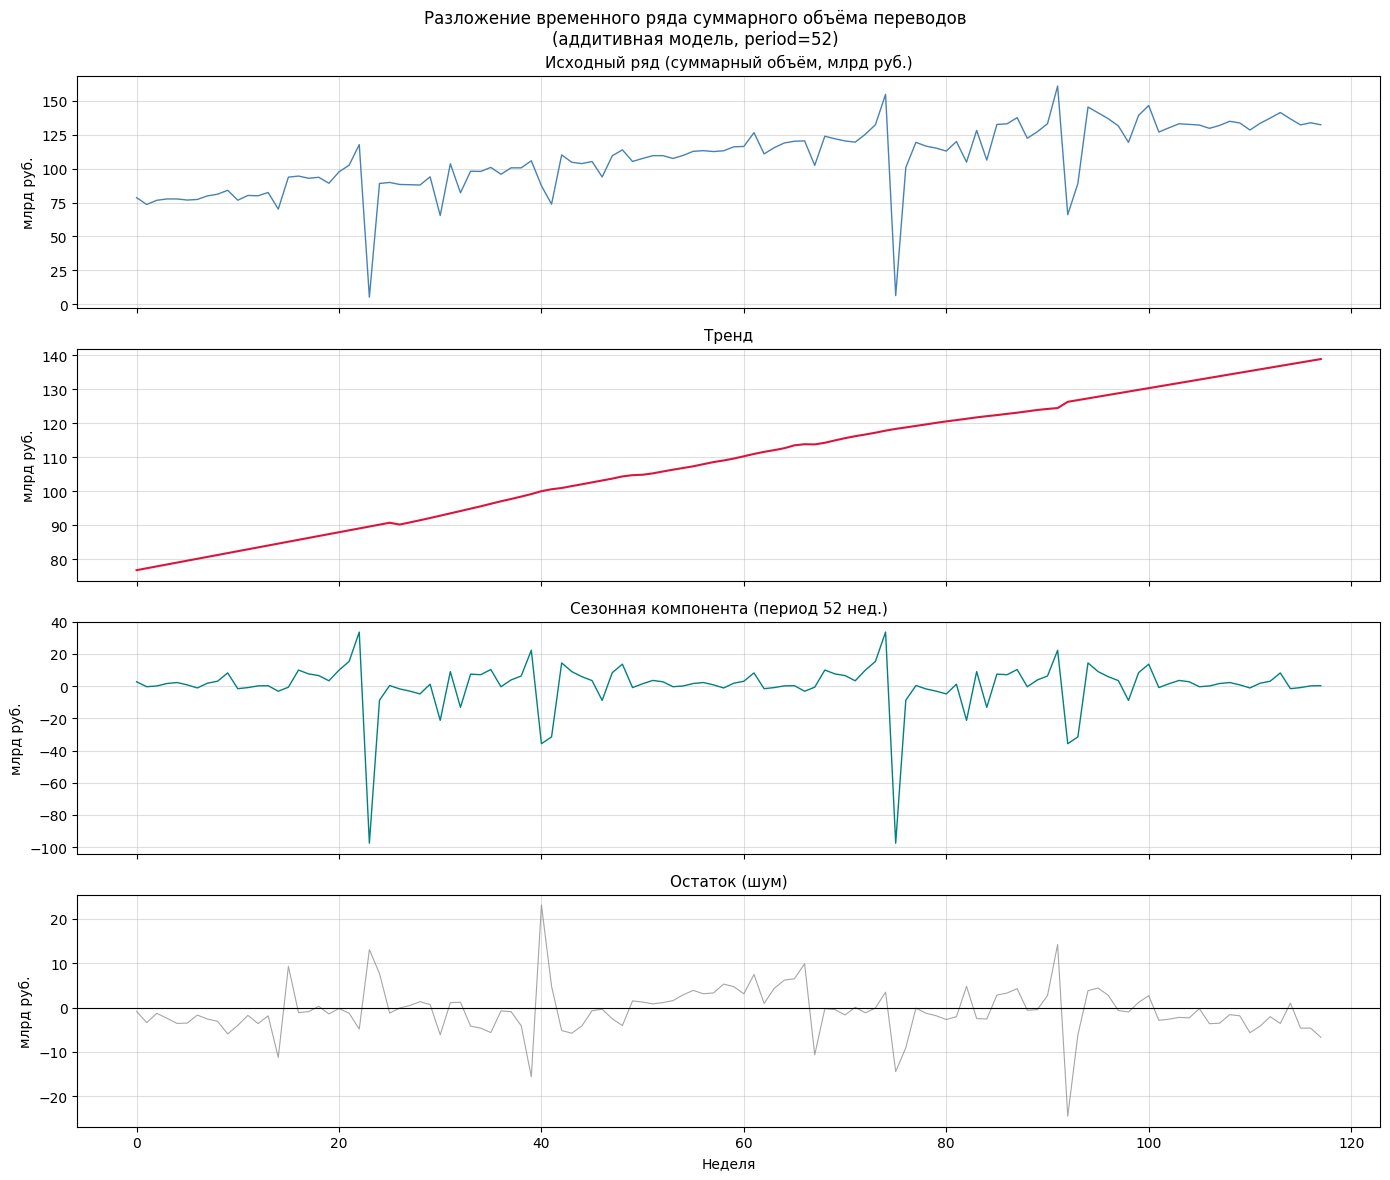

Амплитуда сезонной компоненты: 131.101 млрд руб.
Диапазон тренда:                62.097 млрд руб.
Доля сезонности в общем диапазоне: 67.9%


In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Суммарный ряд уже создан выше как weekly_total
# period=52 — годовая сезонность
ts_for_decomp = weekly_total.set_index('week')['target'] / 1e9

decomp = seasonal_decompose(
    ts_for_decomp, model='additive', period=52, extrapolate_trend='freq'
)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(ts_for_decomp.index, ts_for_decomp.values,
             color='steelblue', linewidth=1)
axes[0].set_title('Исходный ряд (суммарный объём, млрд руб.)', fontsize=11)
axes[0].set_ylabel('млрд руб.')

axes[1].plot(decomp.trend.index, decomp.trend.values,
             color='crimson', linewidth=1.5)
axes[1].set_title('Тренд', fontsize=11)
axes[1].set_ylabel('млрд руб.')

axes[2].plot(decomp.seasonal.index, decomp.seasonal.values,
             color='teal', linewidth=1)
axes[2].set_title('Сезонная компонента (период 52 нед.)', fontsize=11)
axes[2].set_ylabel('млрд руб.')

axes[3].plot(decomp.resid.index, decomp.resid.values,
             color='gray', linewidth=0.8, alpha=0.7)
axes[3].axhline(0, color='black', linewidth=0.8)
axes[3].set_title('Остаток (шум)', fontsize=11)
axes[3].set_ylabel('млрд руб.')
axes[3].set_xlabel('Неделя')

plt.suptitle(
    'Разложение временного ряда суммарного объёма переводов\n'
    '(аддитивная модель, period=52)',
    fontsize=12
)
plt.tight_layout()
plt.savefig(FIG_DIR / '11_decomposition.png', dpi=120, bbox_inches='tight')
plt.show()

seasonal_range = float(decomp.seasonal.max() - decomp.seasonal.min())
trend_range = float(decomp.trend.max() - decomp.trend.min())
print(f'Амплитуда сезонной компоненты: {seasonal_range:.3f} млрд руб.')
print(f'Диапазон тренда:                {trend_range:.3f} млрд руб.')
print(f'Доля сезонности в общем диапазоне: '
      f'{seasonal_range / (seasonal_range + trend_range) * 100:.1f}%')


### 3.9 Проверка стационарности: тест Дики-Фуллера (ADF)

In [28]:
from statsmodels.tsa.stattools import adfuller

def adf_report(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'\n--- ADF тест: {name} ---')
    print(f'  Статистика ADF : {result[0]:.4f}')
    print(f'  p-value        : {result[1]:.4f}')
    print('  Критические значения:')
    for key, val in result[4].items():
        print(f'    {key}: {val:.4f}')
    if result[1] < 0.05:
        print('  >>> ВЫВОД: ряд СТАЦИОНАРЕН (p < 0.05)')
    else:
        print('  >>> ВЫВОД: ряд НЕСТАЦИОНАРЕН (p >= 0.05)')
    return result[1]

p1 = adf_report(ts_for_decomp, 'Суммарный объём (исходный)')


--- ADF тест: Суммарный объём (исходный) ---
  Статистика ADF : -1.0839
  p-value        : 0.7214
  Критические значения:
    1%: -3.4918
    5%: -2.8884
    10%: -2.5811
  >>> ВЫВОД: ряд НЕСТАЦИОНАРЕН (p >= 0.05)


## 4. Построение признаков

In [18]:
# Pivot: клиент x неделя, значение = target
pivot_full = df_all.pivot(index="inn_id", columns="week", values="target").fillna(0)
inn_ids = pivot_full.index.tolist()
N = len(inn_ids)
print(f"Pivot shape: {pivot_full.shape}")
print(f"N clients: {N:,}")


Pivot shape: (51963, 118)
N clients: 51,963


In [29]:
def build_features_from_pivot(pivot, t_week):
    """Строит матрицу признаков для target_week=t_week
    """
    lags = [1, 2, 3, 4, 5, 6, 7, 8, 12, 16, 26, 52]
    windows = [4, 8, 12, 26]
    feat = {}
    
    # Lag-признаки
    for lag in lags:
        w = t_week - lag
        feat[f"lag_{lag}"] = pivot[w].values if w in pivot.columns else np.zeros(N)
    
    # Rolling mean/std/max/min
    for window in windows:
        win_weeks = [w for w in range(t_week - window, t_week) if w in pivot.columns]
        if win_weeks:
            win_data = pivot[win_weeks].values
            feat[f"roll_mean_{window}"] = win_data.mean(axis=1)
            feat[f"roll_std_{window}"]  = win_data.std(axis=1)
            feat[f"roll_max_{window}"]  = win_data.max(axis=1)
            feat[f"roll_min_{window}"]  = win_data.min(axis=1)
        else:
            for s in ["mean","std","max","min"]:
                feat[f"roll_{s}_{window}"] = np.zeros(N)
    
    # Линейный тренд за последние 12 недель
    trend_weeks = [w for w in range(t_week - 12, t_week) if w in pivot.columns]
    if len(trend_weeks) >= 2:
        tw_arr = np.array(trend_weeks, dtype=float)
        tw_c = tw_arr - tw_arr.mean()
        vals = pivot[trend_weeks].values
        cov = (vals * tw_c).mean(axis=1) - vals.mean(axis=1) * tw_c.mean()
        var_x = tw_c.var()
        feat["trend_12w"] = cov / (var_x + 1e-8)
    else:
        feat["trend_12w"] = np.zeros(N)
    
    # То же значение год назад
    w_ly = t_week - 52
    feat["same_week_last_year"] = pivot[w_ly].values if w_ly in pivot.columns else np.zeros(N)
    
    # Временные признаки
    feat["week"] = np.full(N, t_week)
    feat["week_of_year"] = np.full(N, t_week % 52)
    
    return pd.DataFrame(feat, index=pivot.index)


def build_dataset(pivot, target_weeks_list):
    """Строит X и y для набора целевых недель"""
    X_list, y_list = [], []
    for tw in target_weeks_list:
        X_week = build_features_from_pivot(pivot, tw)
        y_week = pivot[tw].values if tw in pivot.columns else np.zeros(N)
        X_list.append(X_week)
        y_list.append(y_week)
    return pd.concat(X_list, ignore_index=True), np.concatenate(y_list)

print(f"Feature set: lag_{{1-8,12,16,26,52}}, roll_{{mean,std,max,min}}_{{4,8,12,26}}, trend_12w, same_week_last_year, week, week_of_year")


Feature set: lag_{1-8,12,16,26,52}, roll_{mean,std,max,min}_{4,8,12,26}, trend_12w, same_week_last_year, week, week_of_year


## 5. Обучение модели (LightGBM)

**Стратегия:**
- Train: целевые недели 52–99 (история 0–51 полная для всех лагов)
- Eval (early stopping): целевые недели 100–105
- Validation proxy: недели 106–109 (validation_public, аналог public lb)
- Финальная модель: обучается на неделях 52–117 (все доступные данные)


In [20]:
# Pivot только train (0-105) для честного split
train_pivot = pivot_full[list(range(0, 106))]

print("Строим train/eval features...")
X_tr, y_tr = build_dataset(train_pivot, list(range(52, 100)))
X_ev, y_ev = build_dataset(train_pivot, list(range(100, 106)))

FEATURE_COLS = list(X_tr.columns)

# Обучаем в log(1+y) пространстве (оптимизируем RMSE → оптимизируем RMSLE)
y_tr_log = np.log1p(y_tr)
y_ev_log = np.log1p(y_ev)

print(f"Train: {X_tr.shape}, Eval: {X_ev.shape}")
print(f"y_train: mean={y_tr_log.mean():.3f}, std={y_tr_log.std():.3f}")


Строим train/eval features...
Train: (2494224, 32), Eval: (311778, 32)
y_train: mean=12.570, std=3.342


Train: (2494224, 32), Eval: (311778, 32)
y_train: mean=12.570, std=3.342


In [13]:
lgb_params = dict(
    objective     = "regression",
    metric        = "rmse",
    n_estimators  = 3000,
    learning_rate = 0.05,
    num_leaves    = 63,
    max_depth     = 7,
    min_child_samples = 100,
    subsample     = 0.8,
    subsample_freq= 1,
    colsample_bytree = 0.8,
    reg_alpha     = 0.05,
    reg_lambda    = 0.5,
    random_state  = 42,
    n_jobs        = -1,
    verbose       = -1,
)

print("Обучение LightGBM...")
model = lgb.LGBMRegressor(**lgb_params)
model.fit(
    X_tr, y_tr_log,
    eval_set=[(X_ev, y_ev_log)],
    callbacks=[
        lgb.early_stopping(100, verbose=True),
        lgb.log_evaluation(100),
    ]
)
print(f"\nBest iteration: {model.best_iteration_}")


Обучение LightGBM...


Training until validation scores don't improve for 100 rounds


[100]	valid_0's rmse: 2.12752


[200]	valid_0's rmse: 2.12075


[300]	valid_0's rmse: 2.11872


...

[500]	valid_0's rmse: 2.11742


[600]	valid_0's rmse: 2.11716


[700]	valid_0's rmse: 2.11712


[800]	valid_0's rmse: 2.11713


Early stopping, best iteration is:
[749]	valid_0's rmse: 2.11701

Best iteration: 749


### 5.1 Feature Importance

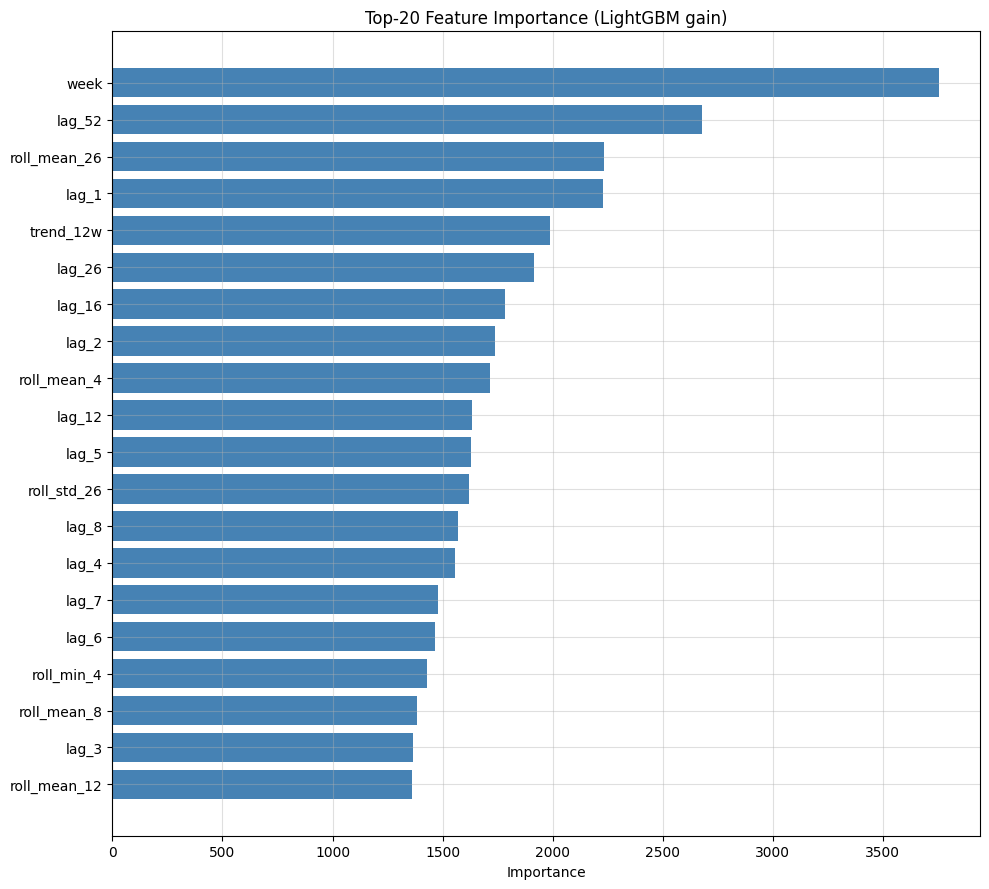

     feature  importance
        week        3755
      lag_52        2681
roll_mean_26        2233
       lag_1        2228
   trend_12w        1990
      lag_26        1915
      lag_16        1785
       lag_2        1739
 roll_mean_4        1715
      lag_12        1632


In [14]:
feat_imp = pd.DataFrame({
    "feature":    FEATURE_COLS,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 9))
top20 = feat_imp.head(20)
ax.barh(top20["feature"][::-1], top20["importance"][::-1], color="steelblue")
ax.set_title("Top-20 Feature Importance (LightGBM gain)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(FIG_DIR / "07_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()
print(feat_imp.head(10).to_string(index=False))


## 6. Валидация — RMSLE

**Важный момент:** модель предсказывает **рекурсивно** (iterative forecasting).  
Для недели 118 все лаги доступны. Для 119 — lag_1 = предсказание 118 и т.д.  
Это аналогично реальной задаче. Валидируем на validation_public (106–109).


In [21]:
def rmsle_per_client(y_true, y_pred, inn_ids_arr):
    """Метрика соревнования: средний RMSLE по клиентам."""
    y_pred_c = np.maximum(0, y_pred)
    df = pd.DataFrame({"inn_id": inn_ids_arr, "y_true": y_true, "y_pred": y_pred_c})
    cr = df.groupby("inn_id").apply(
        lambda g: np.sqrt(np.mean((np.log1p(g["y_true"]) - np.log1p(g["y_pred"]))**2))
    )
    return cr.mean()


In [ ]:
# Iterative forecasting на val_pub (106-109)
# Начинаем с train_pivot (0-105), предсказываем 106, добавляем в pivot, предсказываем 107...
print("Итеративное предсказание val_pub (106-109)...")
pivot_val = train_pivot.copy()
val_results = []

for tw in range(106, 110):
    X_week = build_features_from_pivot(pivot_val, tw)
    pred_log = model.predict(X_week)
    pred = np.maximum(0, np.expm1(pred_log))
    
    true_val = pivot_full[tw].values  # реальные данные из ts_ext
    for inn, pt, pv in zip(inn_ids, true_val, pred):
        val_results.append({"inn_id": inn, "week": tw, "y_true": pt, "y_pred": pv})
    
    pivot_val[tw] = pred  # добавляем предсказание для следующего шага
    print(f"  week {tw}: done")

val_df = pd.DataFrame(val_results)


  week 107: done


  week 108: done


  week 109: done


In [17]:
rmsle_overall = rmsle_per_client(val_df["y_true"].values, val_df["y_pred"].values, val_df["inn_id"].values)
print(f"\n=== RMSLE validation_public (106-109, proxy public LB) ===")
print(f"Общий: {rmsle_overall:.4f}")
print()

for tw in range(106, 110):
    wdf = val_df[val_df["week"] == tw]
    r = rmsle_per_client(wdf["y_true"].values, wdf["y_pred"].values, wdf["inn_id"].values)
    print(f"  week {tw}: {r:.4f}")



=== RMSLE validation_public (106-109, proxy public LB) ===
Общий: 1.4677



  week 106: 1.1146


  week 107: 1.1853


  week 108: 1.2306


  week 109: 1.2589


### 6.1 Распределение ошибок по клиентам

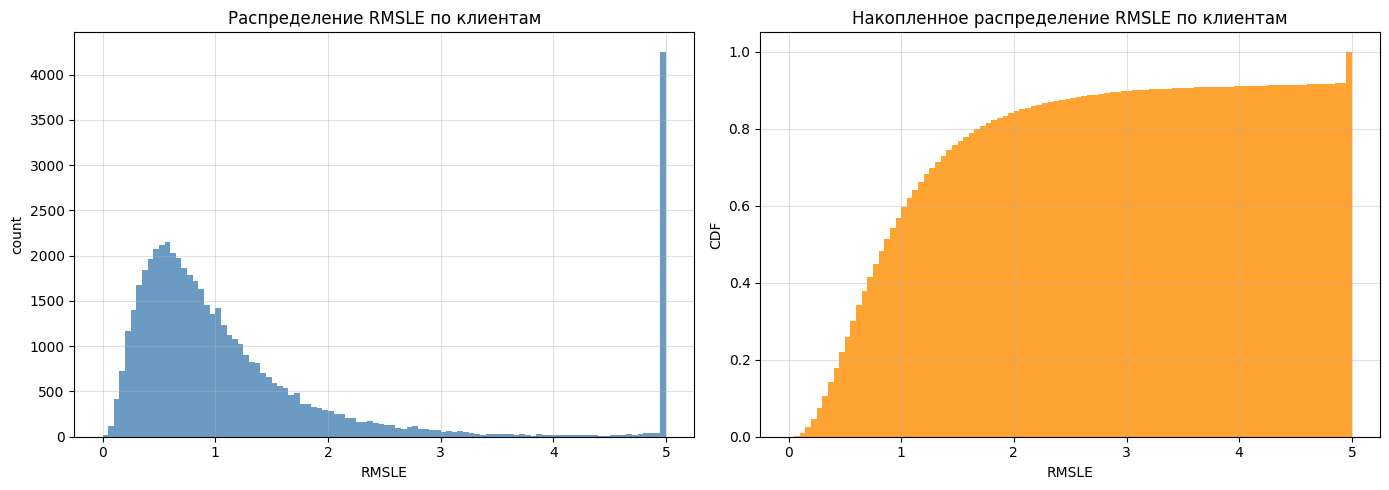

Медиана RMSLE по клиентам: 0.8778
75-й перцентиль:           1.4740
95-й перцентиль:           6.0781


In [18]:
client_rmsle = val_df.groupby("inn_id").apply(
    lambda g: np.sqrt(np.mean((np.log1p(g["y_true"]) - np.log1p(np.maximum(0, g["y_pred"])))**2))
).reset_index(name="rmsle")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(client_rmsle["rmsle"].clip(upper=5), bins=100, color="steelblue", alpha=0.8)
axes[0].set_title("Распределение RMSLE по клиентам")
axes[0].set_xlabel("RMSLE"); axes[0].set_ylabel("count")

axes[1].hist(client_rmsle["rmsle"].clip(upper=5), bins=100, color="darkorange", alpha=0.8, cumulative=True, density=True)
axes[1].set_title("Накопленное распределение RMSLE по клиентам")
axes[1].set_xlabel("RMSLE"); axes[1].set_ylabel("CDF")

plt.tight_layout()
plt.savefig(FIG_DIR / "08_rmsle_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Медиана RMSLE по клиентам: {client_rmsle['rmsle'].median():.4f}")
print(f"75-й перцентиль:           {client_rmsle['rmsle'].quantile(0.75):.4f}")
print(f"95-й перцентиль:           {client_rmsle['rmsle'].quantile(0.95):.4f}")


## 7. Финальная модель и сабмишн

In [19]:
# Дообучаем на всех данных 0-117 с best_iteration
print(f"Обучение финальной модели (all data, n_estimators={model.best_iteration_})...")
X_full, y_full = build_dataset(pivot_full, list(range(52, 118)))
y_full_log = np.log1p(y_full)

model_final = lgb.LGBMRegressor(**{**lgb_params, "n_estimators": model.best_iteration_})
model_final.fit(X_full, y_full_log)
print("Финальная модель обучена.")


Обучение финальной модели (all data, n_estimators=749)...


Финальная модель обучена.


In [20]:
# Рекурсивный прогноз на 12 недель (118-129)
print("Итеративный прогноз (118-129)...")
pivot_forecast = pivot_full.copy()
all_preds = []

for tw in range(118, 130):
    X_week = build_features_from_pivot(pivot_forecast, tw)
    pred_log = model_final.predict(X_week)
    pred = np.maximum(0, np.expm1(pred_log))
    
    for inn, pv in zip(inn_ids, pred):
        all_preds.append({"inn_id": inn, "week": tw, "predict": pv})
    
    pivot_forecast[tw] = pred  # рекурсивно добавляем
    print(f"  week {tw}: mean={pred.mean():,.0f}")

submission = pd.DataFrame(all_preds).sort_values(["inn_id","week"]).reset_index(drop=True)
print(f"\nSubmission shape: {submission.shape}")
print(f"Уникальных клиентов: {submission['inn_id'].nunique():,}")
print(f"Weeks: {sorted(submission['week'].unique())}")
submission.head(15)


Итеративный прогноз (118-129)...


  week 118: mean=1,799,705


  week 119: mean=1,728,456


  week 120: mean=1,833,417


  week 121: mean=1,811,886


...

  week 127: mean=441,301


  week 128: mean=1,280,450


  week 129: mean=1,405,972



Submission shape: (623556, 3)
Уникальных клиентов: 51,963
Weeks: [np.int64(118), np.int64(119), np.int64(120), np.int64(121), np.int64(122), np.int64(123), np.int64(124), np.int64(125), np.int64(126), np.int64(127), np.int64(128), np.int64(129)]


,inn_id,week,predict
0,inn1000051,118,5.894187e+04
1,inn1000051,119,2.158628e+04
2,inn1000051,120,2.173324e+04
3,inn1000051,121,2.333453e+04
4,inn1000051,122,1.118897e+04
5,inn1000051,123,1.002893e+04
6,inn1000051,124,7.581914e+03
7,inn1000051,125,8.713753e+03
8,inn1000051,126,1.037871e+04
9,inn1000051,127,9.365305e+02


### 7.1 Визуализация прогноза vs факт

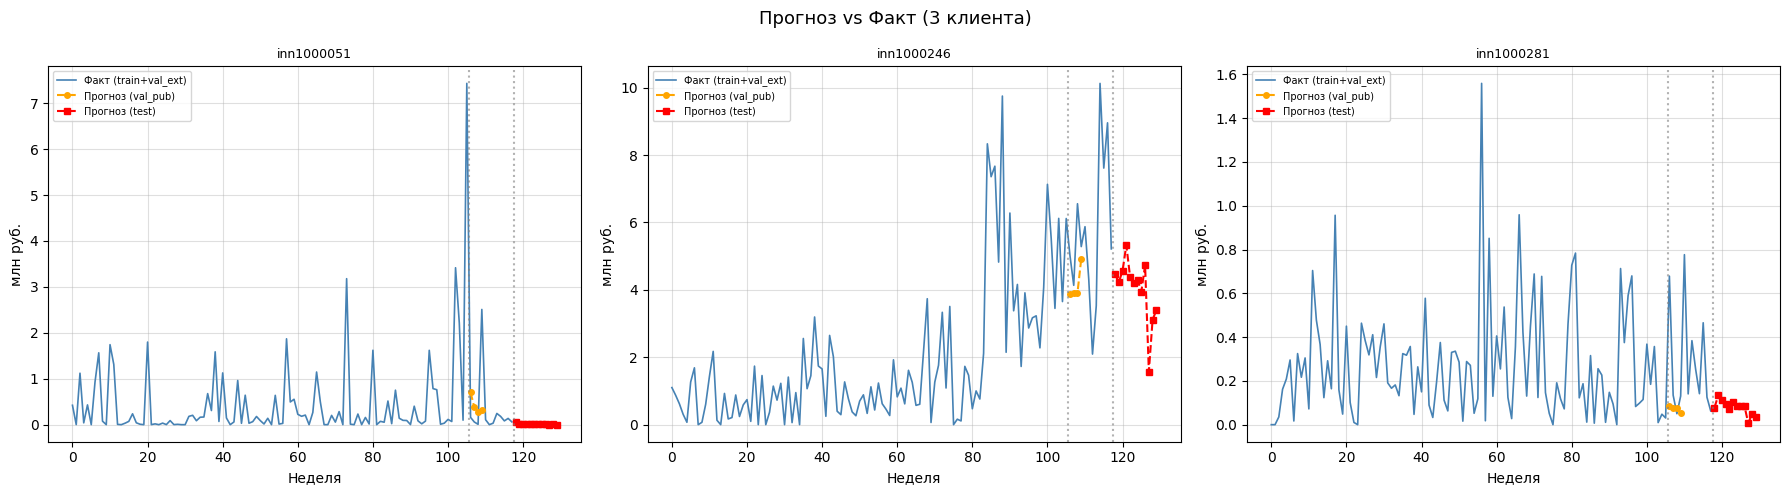

In [21]:
# Выберем несколько клиентов для визуализации
sample_clients = inn_ids[:3]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, client in zip(axes, sample_clients):
    # История
    hist = df_all[df_all["inn_id"] == client].sort_values("week")
    # Прогноз
    fore = submission[submission["inn_id"] == client].sort_values("week")
    # Validation predictions
    val_c = val_df[val_df["inn_id"] == client].sort_values("week")
    
    ax.plot(hist["week"], hist["target"] / 1e6, label="Факт (train+val_ext)", color="steelblue", linewidth=1.2)
    ax.plot(val_c["week"], val_c["y_pred"] / 1e6, label="Прогноз (val_pub)", color="orange",
            linestyle="--", marker="o", markersize=4)
    ax.plot(fore["week"], fore["predict"] / 1e6, label="Прогноз (test)", color="red",
            linestyle="--", marker="s", markersize=4)
    ax.axvline(105.5, color="gray", linestyle=":", alpha=0.6)
    ax.axvline(117.5, color="gray", linestyle=":", alpha=0.6)
    ax.set_title(client, fontsize=9)
    ax.set_xlabel("Неделя"); ax.set_ylabel("млн руб.")
    ax.legend(fontsize=7)

plt.suptitle("Прогноз vs Факт (3 клиента)", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "09_forecast_vs_actual.png", dpi=120, bbox_inches="tight")
plt.show()


In [22]:
# Сохраняем сабмишн
submission.to_csv("submission_lgbm.csv", index=False)
print("Saved: submission_lgbm.csv")

# Проверяем формат vs sample_submit
assert set(submission.columns) == {"inn_id", "week", "predict"}, "Wrong columns!"
assert submission["inn_id"].nunique() == 51963, "Wrong number of clients!"
assert sorted(submission["week"].unique()) == list(range(118, 130)), "Wrong weeks!"
assert (submission["predict"] >= 0).all(), "Negative predictions found!"
print("✓ Формат сабмишна корректен")
print(submission.describe())


Saved: submission_lgbm.csv
✓ Формат сабмишна корректен
                week       predict
count  623556.000000  6.235560e+05
mean      123.500000  1.595220e+06
std         3.452055  5.779593e+06
min       118.000000  0.000000e+00
25%       120.750000  5.710596e+04
50%       123.500000  2.653020e+05
75%       126.250000  1.126820e+06
max       129.000000  1.326698e+08


## 8. Итоги

In [23]:
print("=" * 60)
print("ИТОГИ ЭКСПЕРИМЕНТА")
print("=" * 60)
print(f"Модель:         LightGBM (regression, RMSE на log1p)")
print(f"Признаки:       lag_{{1-8,12,16,26,52}}, rolling_{{4,8,12,26}}, trend, seasonality")
print(f"Обучение:       недели 52–99 (target), eval 100–105")
print(f"Прогноз:        рекурсивный, 118–129 (12 недель)")
print()
print(f"Best iteration: {model.best_iteration_}")
print()
print(f"RMSLE (proxy public LB, weeks 106-109): {rmsle_overall:.4f}")
print()
print("Submission: submission_lgbm.csv")
print(f"  Строк:    {len(submission):,}")
print(f"  Клиентов: {submission['inn_id'].nunique():,}")
print(f"  Недели:   118–129")


ИТОГИ ЭКСПЕРИМЕНТА
Модель:         LightGBM (regression, RMSE на log1p)
Признаки:       lag_{1-8,12,16,26,52}, rolling_{4,8,12,26}, trend, seasonality
Обучение:       недели 52–99 (target), eval 100–105
Прогноз:        рекурсивный, 118–129 (12 недель)

Best iteration: 749

RMSLE (proxy public LB, weeks 106-109): 1.4677

Submission: submission_lgbm.csv
  Строк:    623,556
  Клиентов: 51,963
  Недели:   118–129


**Первое место на val public - 1,4110**

## 9. Предсказание SARIMA

### 9.1 Выбор между ARIMA и SARIMA


In [23]:
print('=' * 65)
print('ВЫВОД: Выбор модели временного ряда')
print('=' * 65)
conclusion = '''
По результатам проведённого анализа:

1. ТРЕНД
   - Суммарный ряд имеет выраженный ВОСХОДЯЩИЙ ТРЕНД.
   - ADF-тест подтвердил нестационарность исходного ряда 
   - Скользящее среднее (4 нед. ≈ 30 дней) наглядно показывает тренд

2. СЕЗОННОСТЬ
   - Разложение выявило ГОДОВУЮ СЕЗОННОСТЬ (период ≈ 52 нед)
   - По месяцам: активность выше в июне–сентябре,
     ниже — в январе и декабре (праздники)
   - Автокорреляция: r(lag=52) ≈ 0.55 — умеренная годовая сезонность

3. ВЫВОД: SARIMA предпочтительнее ARIMA
'''
print(conclusion)


ВЫВОД: Выбор модели временного ряда

По результатам проведённого анализа:

1. ТРЕНД
   - Суммарный ряд имеет выраженный ВОСХОДЯЩИЙ ТРЕНД.
   - ADF-тест подтвердил нестационарность исходного ряда 
   - Скользящее среднее (4 нед. ≈ 30 дней) наглядно показывает тренд

2. СЕЗОННОСТЬ
   - Разложение выявило ГОДОВУЮ СЕЗОННОСТЬ (период ≈ 52 нед)
   - По месяцам: активность выше в июне–сентябре,
     ниже — в январе и декабре (праздники)
   - Автокорреляция: r(lag=52) ≈ 0.55 — умеренная годовая сезонность

3. ВЫВОД: SARIMA предпочтительнее ARIMA



### 9.2 Базовое предсказание SARIMA на агрегированном ряду

In [24]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# Суммарный ряд (недели 0-117, все доступные данные)
ts_sarima = ts_for_decomp.copy()

print('Обучение SARIMA(1,1,1)(1,1,1)[52] на суммарном агрегированном ряду...')
print(f'Длина обучающей выборки: {len(ts_sarima)} недель')

sarima_model = SARIMAX(
    ts_sarima,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False, maxiter=300)
print('Обучение завершено.')
print(sarima_fit.summary().tables[0])


Обучение SARIMA(1,1,1)(1,1,1)[52] на суммарном агрегированном ряду...
Длина обучающей выборки: 118 недель
Обучение завершено.
                                     SARIMAX Results                                      
Dep. Variable:                             target   No. Observations:                  118
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 52)   Log Likelihood                 -27.937
Date:                            Sun, 12 Apr 2026   AIC                             65.874
Time:                                    23:17:09   BIC                             67.864
Sample:                                         0   HQIC                            64.620
                                            - 118                                         
Covariance Type:                              opg                                         


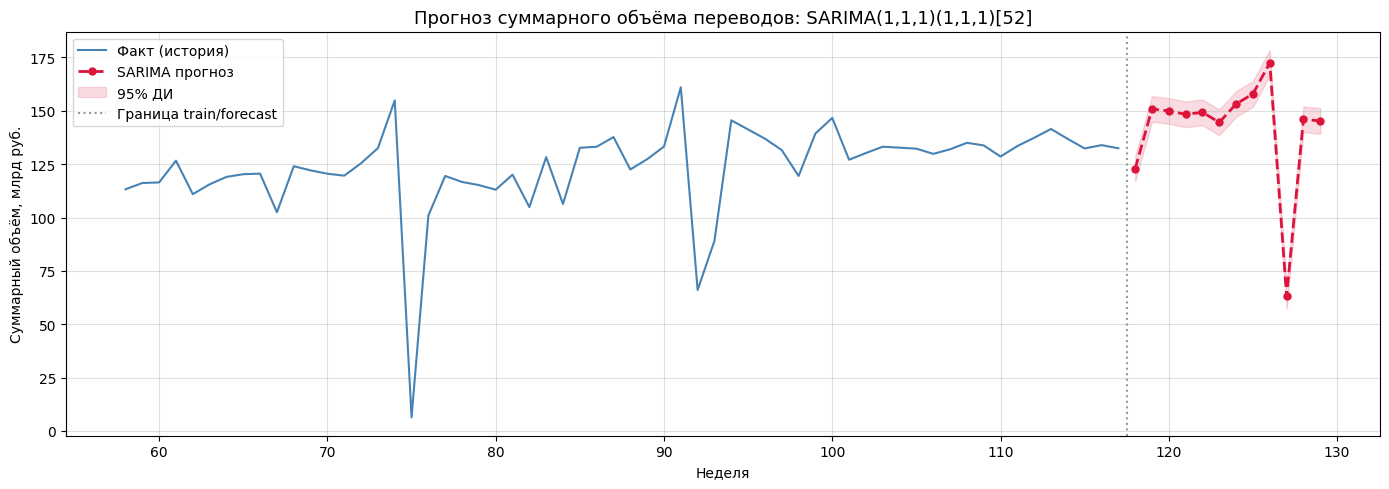


Прогноз SARIMA (суммарный объём, млрд руб.):
  Неделя      Прогноз    Нижн. граница   Верхн. граница
-------------------------------------------------------
     118      122.845          117.020          128.670
     119      150.855          144.863          156.848
     120      149.938          143.927          155.949
     121      148.359          142.345          154.373
     122      149.297          143.282          155.311
     123      144.583          138.569          150.598
     124      153.212          147.197          159.226
     125      157.936          151.921          163.950
     126      172.499          166.485          178.514
     127       63.072           57.058           69.086
     128      146.058          140.043          152.072
     129      145.242          139.227          151.256


In [25]:
# Прогноз на 12 шагов вперёд (недели 118-129)
N_FORECAST = 12
forecast_result = sarima_fit.get_forecast(steps=N_FORECAST)
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int(alpha=0.05)

# Индексируем прогноз правильно (недели 118-129)
forecast_weeks_idx = list(range(118, 130))
forecast_mean.index = forecast_weeks_idx
conf_int.index = forecast_weeks_idx

# Визуализация
fig, ax = plt.subplots(figsize=(14, 5))

# История (последние 60 недель)
hist_plot = ts_for_decomp[ts_for_decomp.index >= 58]
ax.plot(hist_plot.index, hist_plot.values,
        color='steelblue', linewidth=1.5, label='Факт (история)')

# Прогноз
ax.plot(forecast_mean.index, forecast_mean.values,
        color='crimson', linewidth=2, linestyle='--',
        marker='o', markersize=5, label='SARIMA прогноз')

# Доверительный интервал 95%
ax.fill_between(
    forecast_mean.index,
    conf_int.iloc[:, 0].clip(lower=0),
    conf_int.iloc[:, 1],
    color='crimson', alpha=0.15, label='95% ДИ'
)

ax.axvline(117.5, color='gray', linestyle=':', alpha=0.8,
           label='Граница train/forecast')
ax.set_title(
    'Прогноз суммарного объёма переводов: SARIMA(1,1,1)(1,1,1)[52]',
    fontsize=13
)
ax.set_xlabel('Неделя')
ax.set_ylabel('Суммарный объём, млрд руб.')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '12_sarima_forecast.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nПрогноз SARIMA (суммарный объём, млрд руб.):')
hdr = f'{"Неделя":>8} {"Прогноз":>12} {"Нижн. граница":>16} {"Верхн. граница":>16}'
print(hdr)
print('-' * len(hdr))
for w in forecast_weeks_idx:
    lo = conf_int.loc[w].iloc[0]
    hi = conf_int.loc[w].iloc[1]
    print(f'{w:>8} {forecast_mean[w]:>12.3f} {lo:>16.3f} {hi:>16.3f}')


# 10 Идеи и предложения 

**Вопросы**

1. Непонятно, как посчитать RMSLE так как SARIMA работает на агрегированном ряду (сумма по клиентам),
а метрика соревнования считается по каждому клиенту


**Предложения**
1. Заполнить нули данными, оценить полезность на GBM, попробовать разные способы заполнения нулей
2. Добавить больше признаков: ипользовать профили клиентов и транзакционные данные 
3. Обучить модель на CatBoost, попробовать подбор гиппер параметров с помощью Optuna - https://github.com/DanilaAniva/LGBM_Optuna/blob/main/LGBM%20%2B%20Optuna%20-%20%D0%9F%D1%80%D0%BE%D0%B3%D0%BD%D0%BE%D0%B7%20%D0%B7%D0%B0%D0%B4%D0%B5%D1%80%D0%B6%D0%B5%D0%BA%20%D1%81%D0%B0%D0%BC%D0%BE%D0%BB%D0%B5%D1%82%D0%BE%D0%B2%20.ipynb